Upload data via Hugging Face

In [18]:
import sys
import pandas as pd
import spacy

print("Python:", sys.executable)
print("Pandas:", pd.__version__)

nlp = spacy.load("en_core_web_sm")
print("spaCy modeli başarıyla yüklendi.")

Python: /Users/Guclu002/Desktop/mental-health-nlp-preprocessing/venv/bin/python
Pandas: 3.0.3
spaCy modeli başarıyla yüklendi.


In [19]:
import os
from pathlib import Path

hf_home = Path.home() / "Documents" / "huggingface_cache"
hf_home.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(hf_home)
os.environ["HF_DATASETS_CACHE"] = str(hf_home / "datasets")

print("Yeni Hugging Face klasörü:", os.environ["HF_HOME"])

Yeni Hugging Face klasörü: /Users/Guclu002/Documents/huggingface_cache


In [20]:
import os
import getpass

os.environ["HF_TOKEN"] = getpass.getpass("Hugging Face tokenınızı yapıştırın: ")

print("Token geçici olarak tanımlandı.")

Token geçici olarak tanımlandı.


In [21]:
from datasets import load_dataset
import pandas as pd

In [22]:
train_dataset = load_dataset(
    "ourafla/Mental-Health_Text-Classification_Dataset",
    data_files={"train": "mental_heath_unbanlanced.csv"},
    cache_dir=os.environ["HF_DATASETS_CACHE"],
    token=os.environ["HF_TOKEN"],
)

print(train_dataset)

DatasetDict({
    train: Dataset({
        features: ['Unique_ID', 'text', 'status'],
        num_rows: 49612
    })
})


In [23]:
test_dataset = load_dataset(
    "ourafla/Mental-Health_Text-Classification_Dataset",
    data_files={"test": "mental_health_combined_test.csv"},
)

In [24]:
# Convert to Pandas DataFrame:
train_df = train_dataset["train"].to_pandas()
test_df = test_dataset["test"].to_pandas()

print(train_df.head())
print(train_df.shape)

   Unique_ID                                               text   status
0        0.0                                         oh my gosh  Anxiety
1        1.0  trouble sleeping, confused mind, restless hear...  Anxiety
2        2.0  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3        3.0  I've shifted my focus to something else but I'...  Anxiety
4        4.0  I'm restless and restless, it's been a month n...  Anxiety
(49612, 3)


In [25]:
# Save the raw data locally:
train_df.to_csv("../data/raw/mental_health_train_raw.csv", index=False)

test_df.to_csv("../data/raw/mental_health_test_raw.csv", index=False)

In [26]:
# Examining the data for the first time
print(train_df.head())
print(train_df.tail())
print(train_df.sample(5, random_state=42))

   Unique_ID                                               text   status
0        0.0                                         oh my gosh  Anxiety
1        1.0  trouble sleeping, confused mind, restless hear...  Anxiety
2        2.0  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3        3.0  I've shifted my focus to something else but I'...  Anxiety
4        4.0  I'm restless and restless, it's been a month n...  Anxiety
       Unique_ID                                               text  \
49607        NaN  i can't explain it but i know that i don't wan...   
49608        NaN  nobody ever told me that when i started treatm...   
49609        NaN  my wife and i split up in 2012/2013. she had a...   
49610        NaN  A close family member committed suicideI just ...   
49611        NaN  i am a high school english teacher. i am also ...   

           status  
49607  Depression  
49608  Depression  
49609  Depression  
49610    Suicidal  
49611     Anxiety  
       Unique_I

In [27]:
# Check the columns:
print(train_df.columns)
print(train_df.info())

Index(['Unique_ID', 'text', 'status'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 49612 entries, 0 to 49611
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Unique_ID  40012 non-null  float64
 1   text       49612 non-null  str    
 2   status     49612 non-null  str    
dtypes: float64(1), str(2)
memory usage: 20.5 MB
None


How many rows are there? How many columns are there? Are the texts strings? How are the labels written? Are there any missing values? Does the same text appear multiple times? Are the classes balanced?

In [29]:
# Verify the expected columns.
required_columns = {"text", "status"}

missing_columns = required_columns - set(train_df.columns)

if missing_columns:
    raise ValueError(f"Eksik sütunlar bulundu: {missing_columns}")

In [30]:
# Checking for missing values
print(train_df.isnull().sum())

Unique_ID    9600
text            0
status          0
dtype: int64


In [33]:
# In percentage terms:
missing_percentage = (train_df.isnull().mean() * 100).round(2)

print(missing_percentage)

text      0.0
status    0.0
dtype: float64


In [32]:
# Drop
train_df = train_df.drop(columns=["Unique_ID"])

print(train_df.head())

                                                text   status
0                                         oh my gosh  Anxiety
1  trouble sleeping, confused mind, restless hear...  Anxiety
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3  I've shifted my focus to something else but I'...  Anxiety
4  I'm restless and restless, it's been a month n...  Anxiety


In [34]:
# Check for blank text:
empty_texts = train_df[train_df["text"].astype(str).str.strip().eq("")]

print("Boş metin sayısı:", len(empty_texts))

Boş metin sayısı: 0


In [35]:
# Remove any missing text or status records:
df = train_df.copy()

df = df.dropna(subset=["text", "status"])

In [36]:
# Remove empty strings:
df["text"] = df["text"].astype(str).str.strip()
df["status"] = df["status"].astype(str).str.strip()

df = df[df["text"] != ""]
df = df[df["status"] != ""]

Step 8, Step 3 — Examine the labels

In [39]:
print(df["status"].value_counts())

label_distribution = df["status"].value_counts(normalize=True).mul(100).round(2)

print(label_distribution)

status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64
status
Normal        37.07
Depression    29.24
Suicidal      22.60
Anxiety       11.09
Name: proportion, dtype: float64


In [40]:
df["status"] = df["status"].str.strip().str.title()  # Standardize label writing styles

In [43]:
valid_labels = {"Anxiety", "Depression", "Normal", "Suicidal"}

unexpected_labels = set(df["status"].unique()) - valid_labels

print("Beklenmeyen etiketler:", unexpected_labels)

Beklenmeyen etiketler: set()


In [45]:
# To remove unexpected tags
df = df[df["status"].isin(valid_labels)].copy()

Matplotlib is building the font cache; this may take a moment.


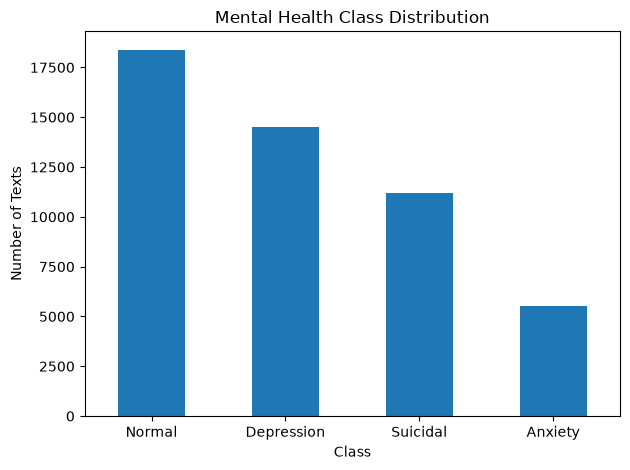

In [46]:
# Class distribution graph
import matplotlib.pyplot as plt

df["status"].value_counts().plot(kind="bar")

plt.title("Mental Health Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Texts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
# Finding duplicate text
duplicate_count = df.duplicated(subset=["text"]).sum()

print("Tekrarlanan metin sayısı:", duplicate_count)

Tekrarlanan metin sayısı: 667


In [ ]:
# See examples
duplicates = df[df.duplicated(subset=["text"], keep=False)].sort_values("text")

print(duplicates.head(20))

In [51]:
# Remove repetitions
df = df.drop_duplicates(subset=["text"]).copy()

In [52]:
# Conflicting tag check: A more significant problem is when the same text has different tags.
label_conflicts = df.groupby("text")["status"].nunique()

conflicting_texts = label_conflicts[label_conflicts > 1].index

print("Çelişkili metin sayısı:", len(conflicting_texts))

Çelişkili metin sayısı: 0


In [53]:
# Çelişkili metinleri kaldırabilirsiniz. This control is important.
# Having the same sentence appear both as "Normal" and "Depression" makes it difficult for the model to learn.
df = df[~df["text"].isin(conflicting_texts)].copy()

In [55]:
# First, we determine the character and word counts.
df["char_count"] = df["text"].str.len()

df["word_count"] = df["text"].str.split().str.len()

print(df[["char_count", "word_count"]].describe())

         char_count    word_count
count  48945.000000  48945.000000
mean     400.246501     78.455123
std      620.582134    122.758607
min        7.000000      1.000000
25%       74.000000     14.000000
50%      243.000000     47.000000
75%      559.000000    110.000000
max    38785.000000   9684.000000


In [57]:
# Average according to the label
length_by_class = df.groupby("status")[["char_count", "word_count"]].mean().round(2)

print(length_by_class)

            char_count  word_count
status                            
Anxiety         656.34      124.45
Depression      536.06      106.34
Normal          124.55       23.70
Suicidal        552.24      109.81


In [58]:
# View very short texts
short_texts = df[df["word_count"] < 3]
print(short_texts[["text", "status"]].head(20))

# View very long texts
long_texts = df.sort_values("word_count", ascending=False).head(10)
print(long_texts[["text", "status", "word_count"]])

                    text   status
283          restless eh  Anxiety
301         very nervous  Anxiety
317         Very worried  Anxiety
320          Too nervous  Anxiety
330    Waiting anxiously  Anxiety
338     Feeling restless  Anxiety
341        very restless  Anxiety
373     Restless tonight  Anxiety
376        Still hopeful  Anxiety
732         No comeback~   Normal
740          Hurry bruh!   Normal
754        Room cleaning   Normal
765        Pack timeeeee   Normal
777      punyetaaaaaa ™‚   Normal
828           SEBASTIANN   Normal
850       morning bestie   Normal
869       Shame brother.   Normal
887       Alhamdulillah!   Normal
891  Rikiyat hhhhhhhhhhh   Normal
896          potta cloth   Normal
                                                    text      status  \
42898  Get out of my head.Get out of my head. Get out...    Suicidal   
42645  What do you guys think about my book? \n the b...      Normal   
42937  Ahem, excuse me while I rehearse the speech I’...      Normal  

In [59]:
df = df[df["word_count"].between(3, 500)].copy()

In [60]:
# Basic text cleanup // We will create two different text columns: text_light_clean: Lightly cleaned text,
#  text_lemma: Classic NLP text with lemmatization applied.

import re
import html
import unicodedata

In [63]:
def light_clean_text(text: str) -> str:
    """
    Metnin anlamını mümkün olduğunca koruyarak
    temel format temizliği yapar.
    """

    if not isinstance(text, str):
        return ""

    # HTML karakterlerini dönüştürür:
    # &amp; -> &
    text = html.unescape(text)

    # Unicode biçimini standartlaştırır
    text = unicodedata.normalize("NFKC", text)

    # Web adreslerini özel bir token ile değiştirir
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)

    # E-posta adreslerini anonimleştirir
    text = re.sub(r"\b[\w.-]+?@\w+?\.\w+?\b", " EMAIL ", text)

    # Reddit kullanıcı adları
    text = re.sub(r"\bu/[A-Za-z0-9_-]+\b", " USER ", text)

    # @kullanıcı adları
    text = re.sub(r"@\w+", " USER ", text)

    # Fazla boşlukları temizler
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [65]:
df["text_light_clean"] = df["text"].apply(light_clean_text)

In [66]:
# We generally use a lowercase in Classic TF-IDF models.

df["text_lower"] = df["text_light_clean"].str.lower()

In [67]:
def uppercase_ratio(text: str) -> float:
    letters = [char for char in text if char.isalpha()]

    if not letters:
        return 0.0

    uppercase_letters = [char for char in letters if char.isupper()]

    return len(uppercase_letters) / len(letters)

In [68]:
df["uppercase_ratio"] = df["text"].apply(uppercase_ratio)

In [69]:
# Punctuation
df["exclamation_count"] = df["text"].str.count("!")

df["question_count"] = df["text"].str.count(r"\?")

df["ellipsis_count"] = df["text"].str.count(r"\.{3,}")

In [72]:
# Repetitive punctuation
def count_repeated_punctuation(text: str) -> int:
    patterns = re.findall(r"(!{2,}|\?{2,}|\.{3,})", text)
    return len(patterns)

In [73]:
df["repeated_punctuation_count"] = df["text"].apply(count_repeated_punctuation)

In [75]:
# Emoji features
import emoji


def count_emojis(text: str) -> int:
    return sum(1 for char in text if emoji.is_emoji(char))

In [76]:
df["emoji_count"] = df["text"].apply(count_emojis)

In [77]:
def convert_emojis_to_text(text: str) -> str:
    return emoji.demojize(text, delimiters=(" ", " "))

In [78]:
df["text_with_emoji_words"] = df["text_light_clean"].apply(convert_emojis_to_text)

In [81]:
# Tokenization: Tokenization is the process of breaking text down into smaller parts.
# Stopwords are frequently used words.
# Lemmatization finds the dictionary form of the word.

import spacy

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

In [82]:
# NLP preprocessing function

NEGATION_WORDS = {"no", "not", "nor", "never", "neither", "n't"}

In [83]:
def preprocess_for_classical_nlp(text: str) -> str:
    """
    TF-IDF ve klasik ML modelleri için:
    - Tokenization
    - Lowercasing
    - Lemmatization
    - Seçici stopword removal
    """

    if not isinstance(text, str):
        return ""

    doc = nlp(text)

    cleaned_tokens = []

    for token in doc:
        token_lower = token.text.lower().strip()

        # Boşlukları atla
        if token.is_space:
            continue

        # Noktalama işaretlerini atla
        if token.is_punct:
            continue

        # Sayıları NUM tokenıyla değiştir
        if token.like_num:
            cleaned_tokens.append("NUM")
            continue

        # Stopwordleri çıkar fakat olumsuzlukları koru
        if token.is_stop and token_lower not in NEGATION_WORDS:
            continue

        lemma = token.lemma_.lower().strip()

        # Özel tokenları koru
        if token.text in {"URL", "EMAIL", "USER"}:
            cleaned_tokens.append(token.text)
            continue

        # Yalnızca anlamlı tokenları ekle
        if lemma and len(lemma) > 1:
            cleaned_tokens.append(lemma)

    return " ".join(cleaned_tokens)

In [84]:
df["text_lemma"] = df["text_light_clean"].apply(preprocess_for_classical_nlp)

In [ ]:
print(
    df[["text", "text_light_clean", "text_lemma"]]
    .sample(10, random_state=42)
    .to_string(index=False)
)

In [86]:
# Büyük veri üzerinde daha hızlı preprocessing
def preprocess_documents(texts):
    processed_texts = []

    for doc in nlp.pipe(texts, batch_size=500):
        cleaned_tokens = []

        for token in doc:  # Here, spaCy breaks the text down into words.
            token_lower = (
                token.text.lower().strip()
            )  # It converts uppercase letters to lowercase. It removes the spaces at the beginning and end of the letters.

            if token.is_space:
                continue

            if token.is_punct:
                continue

            if token.like_num:
                cleaned_tokens.append("NUM")
                continue

            if (
                token.is_stop  # Stopwords are being deleted here.
                and token_lower not in NEGATION_WORDS
            ):
                continue

            if token.text in {"URL", "EMAIL", "USER"}:
                cleaned_tokens.append(token.text)
                continue

            lemma = token.lemma_.lower().strip()  # The model sees the root of the word.

            if lemma and len(lemma) > 1:
                cleaned_tokens.append(lemma)

        processed_texts.append(  # She puts all the words back together.
            " ".join(cleaned_tokens)
        )

    return processed_texts

In [87]:
df["text_lemma"] = preprocess_documents(df["text_light_clean"].tolist())

In [88]:
# Checking for blank clean text
empty_after_processing = df[df["text_lemma"].str.strip().eq("")]

print("Preprocessing sonrası boş kalan kayıt:", len(empty_after_processing))

Preprocessing sonrası boş kalan kayıt: 123


In [89]:
df = df[df["text_lemma"].str.strip().ne("")].copy()